# **직접 만든 데이터로 파인튜닝**

# 1.환경준비

## (1) 라이브러리 설치

In [1]:
!pip install ultralytics roboflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 39.4 MB/s eta 0:00:00


## (2) 라이브러리 불러오기

In [2]:
from ultralytics import settings, YOLO
import matplotlib.pyplot as plt
import cv2
import os
from IPython.display import Video

from roboflow import Roboflow

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


* 폴더 내 이미지 개수 확인

In [3]:
def image_count(path) :
    image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]  # YOLO에서 지원하는 이미지 확장자

    # valid 폴더에서 이미지 파일 개수 확인
    image_count = len([f for f in os.listdir(path) if f.lower().endswith(tuple(image_extensions))])

    return image_count

## (3) YOLO 설정

* 파일 경로 설정

In [4]:
# 콜랩 파일 탭에 보이는 경로('/content/')로 변경해 봅시다.
settings['datasets_dir'] = '/content/'
settings.update()
settings

{'settings_version': '0.0.6',
 'datasets_dir': '/content/',
 'weights_dir': 'weights',
 'runs_dir': 'runs',
 'uuid': '569f3ba64b326db489132663f79cd37279811de477381b83ac131e6cdd129cbb',
 'sync': True,
 'api_key': '',
 'openai_api_key': '',
 'clearml': True,
 'comet': True,
 'dvc': True,
 'hub': True,
 'mlflow': True,
 'neptune': True,
 'raytune': True,
 'tensorboard': False,
 'wandb': False,
 'vscode_msg': True,
 'openvino_msg': True}

# 2.모델링

## (1) 데이터셋 다운로드

In [5]:
rf = Roboflow(api_key="oFyNbRkwU6FgJ7qvcFn5")
project = rf.workspace("hanky-z2qrh").project("my-first-project-3ytdb")
version = project.version(2)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to My-First-Project-2 in yolov11:: 100%|██████████| 190/190 [00:00<00:00, 4174.05it/s]


* 이미지 개수 확인

In [6]:
# train 이미지

cnt = image_count('/content/My-First-Project-2/train/images')
print('* train 이미지 수 :', cnt)

# valid 이미지
cnt = image_count('/content/My-First-Project-2/valid/images')
print('* valid 이미지 수 :', cnt)

* train 이미지 수 : 81
* valid 이미지 수 : 10


## (2) 모델 다운로드

- 모델의 구조와 해당 구조에 맞게 사전 학습된 가중치를 불러온다.
- Parameters
    * model : 모델 구조 또는 모델 구조 + 가중치 설정. task와 맞는 모델을 선택해야 한다.
    * task : detect, segment, classify, pose 중 택일

In [7]:
model = YOLO(model='yolo11n.pt', task='detect')

## (3) 파인튜닝

* 모델 학습
    * 파라미터 설명 : [Parameters](https://docs.ultralytics.com/modes/train/#train-settings)

In [8]:
results_train = model.train(model='/content/yolov11n.pt',
                            data='/content/My-First-Project-2/data.yaml',
                            epochs=20,
                            seed=20,
                            optimizer = 'Adam',
                            pretrained=True,
                            lr0 = 0.0001
                            )

Ultralytics 8.3.204 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/My-First-Project-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolov11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patience=100, perspective=0.

## (4) 평가

In [9]:
# 테스트 이미지로 모델 평가하기
results = model.val(data='/content/My-First-Project-2/data.yaml', split="val")

Ultralytics 8.3.204 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1481.9±315.5 MB/s, size: 41.5 KB)
val: Scanning /content/My-First-Project-2/valid/labels.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 21.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.0it/s 0.3s
                   all         10         15      0.769      0.884      0.899      0.741
                  Bang          8          8      0.884      0.957      0.967      0.797
                  Suni          7          7      0.653      0.811       0.83      0.684
Speed: 3.1ms preprocess, 21.3ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/runs/detect/train2


## (5) 예측해보기

In [10]:
image_path = '/content/My-First-Project-2/train/images/KakaoTalk_20250318_150332763_03_jpg.rf.73c3af08420ec866c065ced160a8be7d.jpg'


image 1/1 /content/My-First-Project-2/train/images/KakaoTalk_20250318_150332763_03_jpg.rf.73c3af08420ec866c065ced160a8be7d.jpg: 640x640 2 Sunis, 7.9ms
Speed: 1.9ms preprocess, 7.9ms inference, 6.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/train3


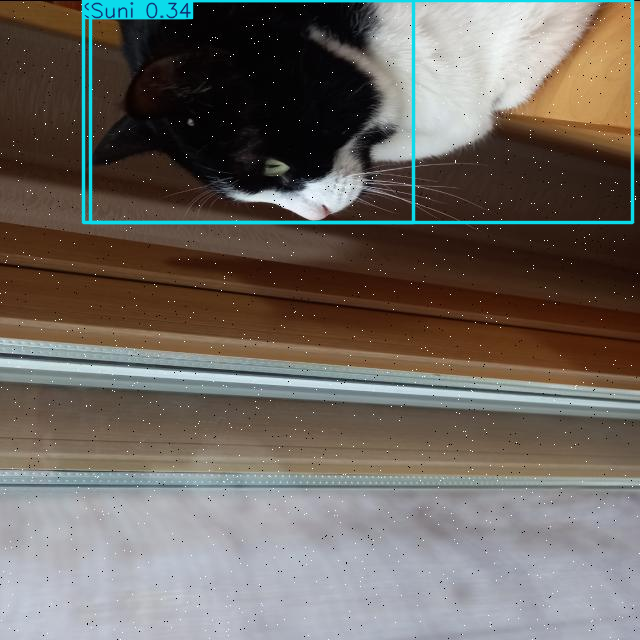

In [11]:
result = model.predict(source=image_path, save=True, conf = 0.1)
result[0].show()  # 탐지된 객체 출력